<a href="https://colab.research.google.com/github/sowmyasameer4/ML-DL-Projects/blob/main/Diabetes_Prediction/PROJECT(4)(Diabetes_Dataset)ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **PROBLEM STATEMENT**

Diabetes mellitus is a chronic metabolic disorder that affects millions worldwide and is associated with significant morbidity and mortality.
The goal of this study is to develop a predictive model to classify a patient’s current diabetes status based on their demographic profile and historical clinical information. Additionally, the study aims to identify key factors contributing to diabetes risk across different patient subgroups. This could be approached as a binary classification problem, where the model learns patterns from the other variables to predict the likelihood of diabetes (0 for no, 1 for yes).

The objective of this study is to develop a predictive model that can accurately identify patients who currently have diabetes using demographic and clinical features.By leveraging patient information such as race, age, gender, and historical clinical data, the study aims to uncover key factors that contribute to diabetes risk and progression

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Datasets/diabetes_dataset_with_notes.csv")
df

,year,gender,age,location,race:AfricanAmerican,race:Asian,race:Caucasian,race:Hispanic,race:Other,hypertension,heart_disease,smoking_history,bmi,hbA1c_level,blood_glucose_level,diabetes,clinical_notes
0,2020,Female,32.0,Alabama,0,0,0,0,1,0,0,never,27.32,5.0,100,0,"Overweight, advised dietary and exercise modif..."
1,2015,Female,29.0,Alabama,0,1,0,0,0,0,0,never,19.95,5.0,90,0,Healthy BMI range.
2,2015,Male,18.0,Alabama,0,0,0,0,1,0,0,never,23.76,4.8,160,0,"Young patient, generally lower risk but needs ..."
3,2015,Male,41.0,Alabama,0,0,1,0,0,0,0,never,27.32,4.0,159,0,"Overweight, advised dietary and exercise modif..."
4,2016,Female,52.0,Alabama,1,0,0,0,0,0,0,never,23.75,6.5,90,0,"Healthy BMI range. High HbA1c level, indicativ..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,2018,Female,33.0,Wyoming,0,0,0,0,1,0,0,never,21.21,6.5,90,0,"Healthy BMI range. High HbA1c level, indicativ..."
99996,2016,Female,80.0,Wyoming,0,1,0,0,0,0,0,No Info,36.66,5.7,100,0,Elderly patient with increased risk of chronic...
99997,2018,Male,46.0,Wyoming,0,1,0,0,0,0,0,ever,36.12,6.2,158,0,"Obese category, increased risk for diabetes an..."
99998,2018,Female,51.0,Wyoming,1,0,0,0,0,0,0,not current,29.29,6.0,155,0,"Overweight, advised dietary and exercise modif..."


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 17 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   year                  100000 non-null  int64  
 1   gender                100000 non-null  object 
 2   age                   100000 non-null  float64
 3   location              100000 non-null  object 
 4   race:AfricanAmerican  100000 non-null  int64  
 5   race:Asian            100000 non-null  int64  
 6   race:Caucasian        100000 non-null  int64  
 7   race:Hispanic         100000 non-null  int64  
 8   race:Other            100000 non-null  int64  
 9   hypertension          100000 non-null  int64  
 10  heart_disease         100000 non-null  int64  
 11  smoking_history       100000 non-null  object 
 12  bmi                   100000 non-null  float64
 13  hbA1c_level           100000 non-null  float64
 14  blood_glucose_level   100000 non-null  int64  
 15  d

In [ ]:
df.isnull().sum()

,0
year,0
gender,0
age,0
location,0
race:AfricanAmerican,0
race:Asian,0
race:Caucasian,0
race:Hispanic,0
race:Other,0
hypertension,0


In [ ]:
df.duplicated().sum()

np.int64(14)

##  **Visualization**

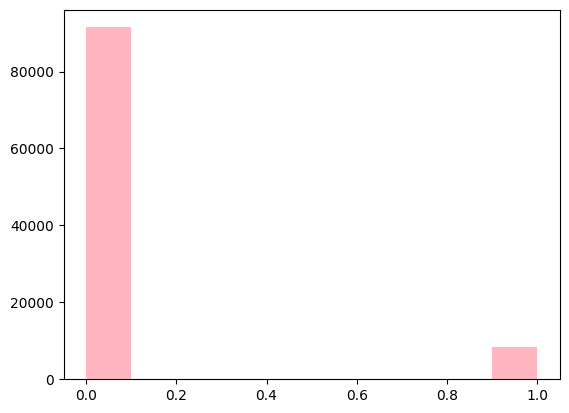

In [ ]:
plt.hist(df["diabetes"], color='#FFB6C1')
plt.show()

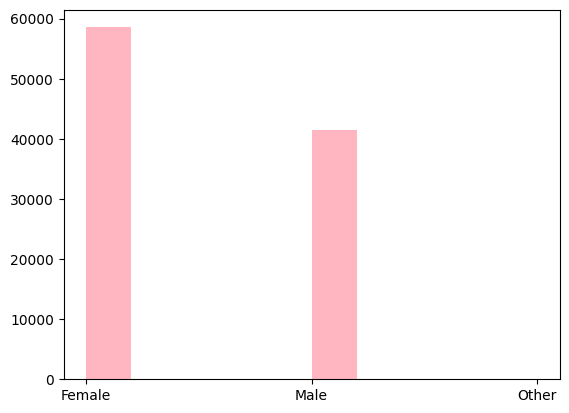

In [ ]:
plt.hist(df["gender"], color='#FFB6C1')
plt.show()

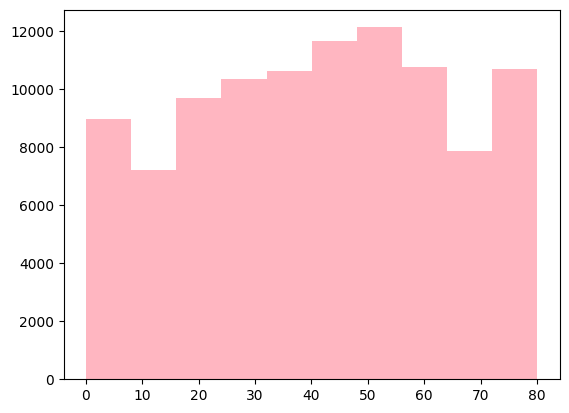

In [ ]:
plt.hist(df["age"], color='#FFB6C1')
plt.show()

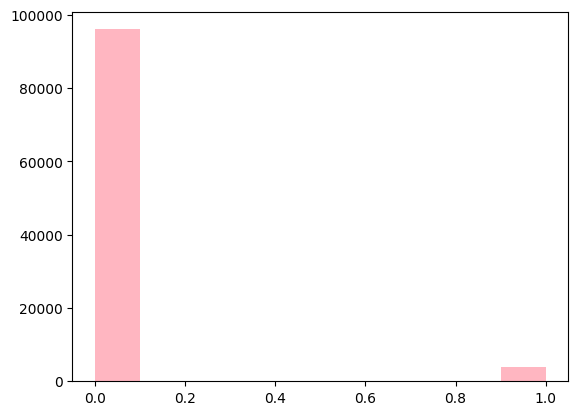

In [ ]:
plt.hist(df["heart_disease"], color='#FFB6C1')
plt.show()

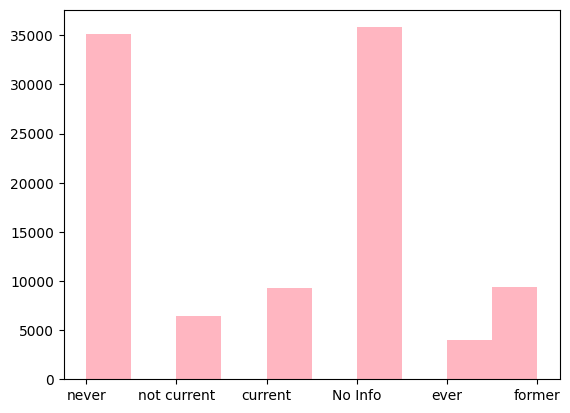

In [ ]:
plt.hist(df["smoking_history"], color='#FFB6C1')
plt.show()

## Cleaning Data

In [ ]:
df["gender"].replace(["Male","Female","Other"],[0,1,2], inplace=True)


/tmp/ipykernel_355/1070951863.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["gender"].replace(["Male","Female","Other"],[0,1,2], inplace=True)
/tmp/ipykernel_355/1070951863.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["gender"].replace(["Male","Female","Other"],[0,1,2], inplace=Tr

In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

df['location'] = le.fit_transform(df['location'])


In [ ]:
df['smoking_history'].unique()

array(['never', 'not current', 'current', 'No Info', 'ever', 'former'],
      dtype=object)

In [ ]:
df["smoking_history"].replace(["No Info","never","not current","former","ever","current"], [0,1,2,3,4,5], inplace=True)

/tmp/ipykernel_355/3364691823.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["smoking_history"].replace(["No Info","never","not current","former","ever","current"], [0,1,2,3,4,5], inplace=True)
/tmp/ipykernel_355/3364691823.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["smoking_hist

In [ ]:
df['clinical_notes'].unique()

array(['Overweight, advised dietary and exercise modifications.',
       'Healthy BMI range.',
       'Young patient, generally lower risk but needs lifestyle assessment. Healthy BMI range. Elevated blood glucose levels, potential diabetes concern.',
       'Overweight, advised dietary and exercise modifications. Elevated blood glucose levels, potential diabetes concern.',
       'Healthy BMI range. High HbA1c level, indicative of diabetes or poor glucose control. Higher predisposition to hypertension and diabetes.',
       'Elderly patient with increased risk of chronic conditions. Overweight, advised dietary and exercise modifications. Elevated blood glucose levels, potential diabetes concern. History of smoking, potential lung and vascular health impact.',
       'Healthy BMI range. History of smoking, potential lung and vascular health impact.',
       'Young patient, generally lower risk but needs lifestyle assessment. Healthy BMI range. Elevated blood glucose levels, potential di

In [ ]:
df["clinical_notes"]=le.fit_transform(df["clinical_notes"])

### Combining multiple Race columns(5) into single race column

In [ ]:
race_cols = ['race:AfricanAmerican', 'race:Asian', 'race:Caucasian', 'race:Hispanic', 'race:Other']

# Combine into a single 'race' column
def combine_race(row):
    for col in race_cols:
        if row[col] == 1:  # assuming 1 indicates presence
            return col.split(':')[1]  # get the race name after ':'
    return 'Unknown'  # if none are 1

df['race_combined'] = df.apply(combine_race, axis=1)

# Drop the original one-hot columns if needed
# df = df.drop(columns=race_cols)

# Check result
print(df[['race_combined']].head())


     race_combined
0            Other
1            Asian
2            Other
3        Caucasian
4  AfricanAmerican


In [ ]:
# List of race columns
race_cols = ['race:AfricanAmerican', 'race:Asian', 'race:Caucasian', 'race:Hispanic', 'race:Other']

# Create a single 'race_combined' column using idxmax (fast for one-hot)
df['race_combined'] = df[race_cols].idxmax(axis=1).str.split(':').str[1]

# Optional: if all zeros (no race info), set as 'Unknown'
df.loc[df[race_cols].sum(axis=1) == 0, 'race_combined'] = 'Unknown'

# Drop original one-hot columns if you want
df = df.drop(columns=race_cols)

In [ ]:
df["race_combined"].unique()

array(['Other', 'Asian', 'Caucasian', 'AfricanAmerican', 'Hispanic'],
      dtype=object)

In [ ]:
df['race_combined'] = le.fit_transform(df['race_combined'])

In [ ]:
df

,year,gender,age,location,hypertension,heart_disease,smoking_history,bmi,hbA1c_level,blood_glucose_level,diabetes,clinical_notes,race_combined
0,2020,1,32.0,0,0,0,1,27.32,5.0,100,0,508,4
1,2015,1,29.0,0,0,0,1,19.95,5.0,90,0,341,1
2,2015,0,18.0,0,0,0,1,23.76,4.8,160,0,635,4
3,2015,0,41.0,0,0,0,1,27.32,4.0,159,0,516,2
4,2016,1,52.0,0,0,0,1,23.75,6.5,90,0,394,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,2018,1,33.0,54,0,0,1,21.21,6.5,90,0,388,4
99996,2016,1,80.0,54,0,0,0,36.66,5.7,100,0,185,1
99997,2018,0,46.0,54,0,0,4,36.12,6.2,158,0,468,1
99998,2018,1,51.0,54,0,0,2,29.29,6.0,155,0,560,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 13 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   year                 100000 non-null  int64  
 1   gender               100000 non-null  int64  
 2   age                  100000 non-null  float64
 3   location             100000 non-null  int64  
 4   hypertension         100000 non-null  int64  
 5   heart_disease        100000 non-null  int64  
 6   smoking_history      100000 non-null  int64  
 7   bmi                  100000 non-null  float64
 8   hbA1c_level          100000 non-null  float64
 9   blood_glucose_level  100000 non-null  int64  
 10  diabetes             100000 non-null  int64  
 11  clinical_notes       100000 non-null  int64  
 12  race_combined        100000 non-null  int64  
dtypes: float64(3), int64(10)
memory usage: 9.9 MB


### Over Sampling Using SMOTE because of Imbalanced Target

In [ ]:
from imblearn.over_sampling import SMOTE

x = df.drop("diabetes", axis=1)
y = df["diabetes"]

smote = SMOTE(random_state=42)
x_resampled, y_resampled = smote.fit_resample(x,y)

In [ ]:
df.smote = x_resampled.copy()
df.smote["diabetes"] = y_resampled

/tmp/ipykernel_355/2135696259.py:1: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  df.smote = x_resampled.copy()


array([[<Axes: title={'center': 'diabetes'}>]], dtype=object)

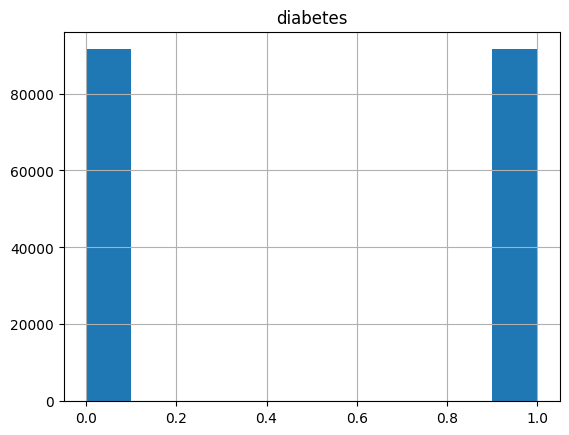

In [ ]:
df.smote.hist("diabetes")

In [ ]:
df = df.smote

## **Correlation**

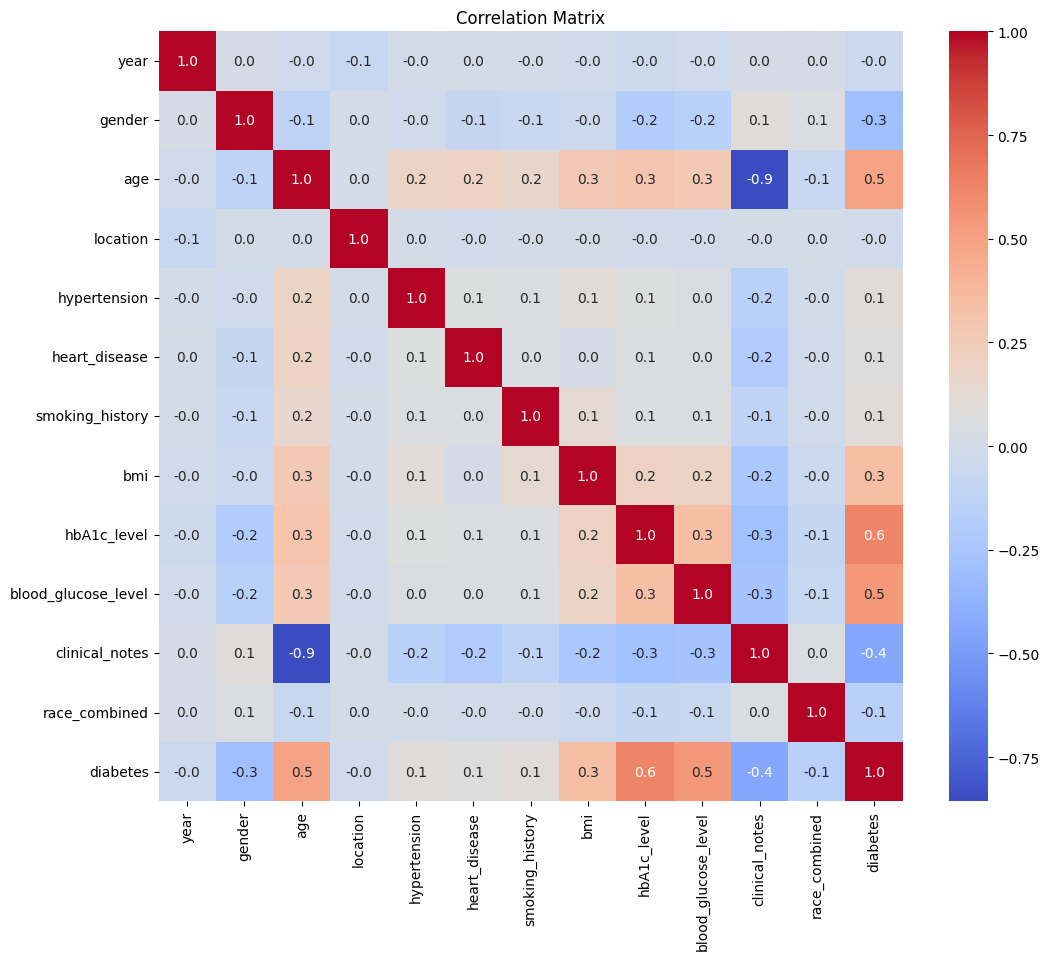

In [ ]:
plt.figure(figsize=(12,10))
corr_matrix = df.corr()

sns.heatmap(corr_matrix, annot=True, fmt='0.01f', cmap='coolwarm')
plt.title('Correlation Matrix')

plt.show()


In [ ]:
df.drop(["clinical_notes"], axis=1, inplace=True)

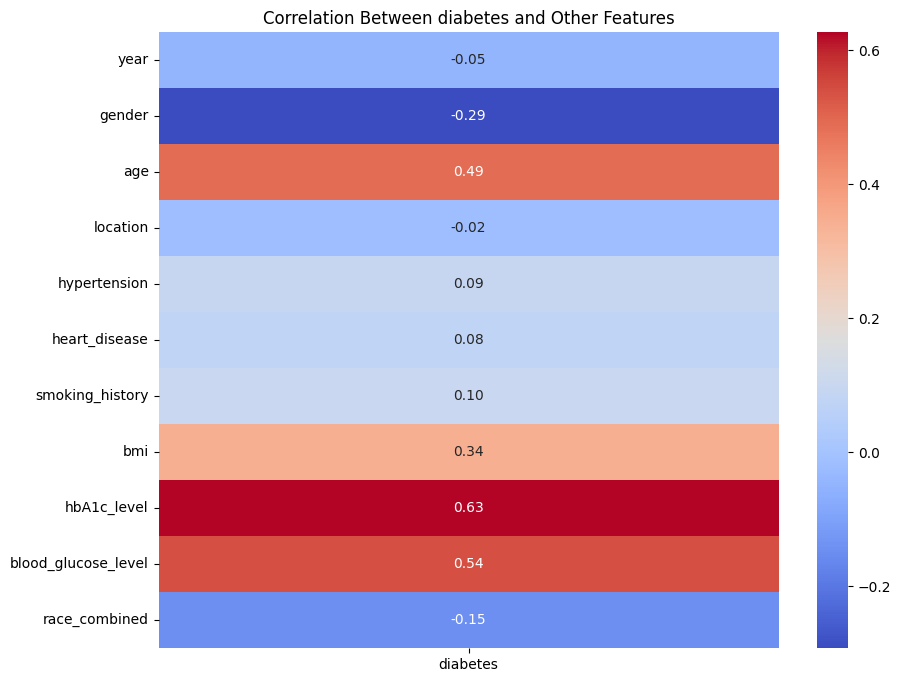

In [ ]:
#calculate the correlation between diabetes and other variables
plt.figure(figsize=(10,8))
diabetes_corr = df.corr()['diabetes']

diabetes_corr = diabetes_corr.drop('diabetes')

sns.heatmap(diabetes_corr.to_frame(), annot=True, fmt='.2f', cmap='coolwarm',
            cbar=True, annot_kws={'size': 10})
plt.title('Correlation Between diabetes and Other Features')
plt.show()

In [ ]:
df.drop(["year","location","hypertension","heart_disease","smoking_history","race_combined"], axis=1, inplace=True)

## Checking Outliers

<Axes: >

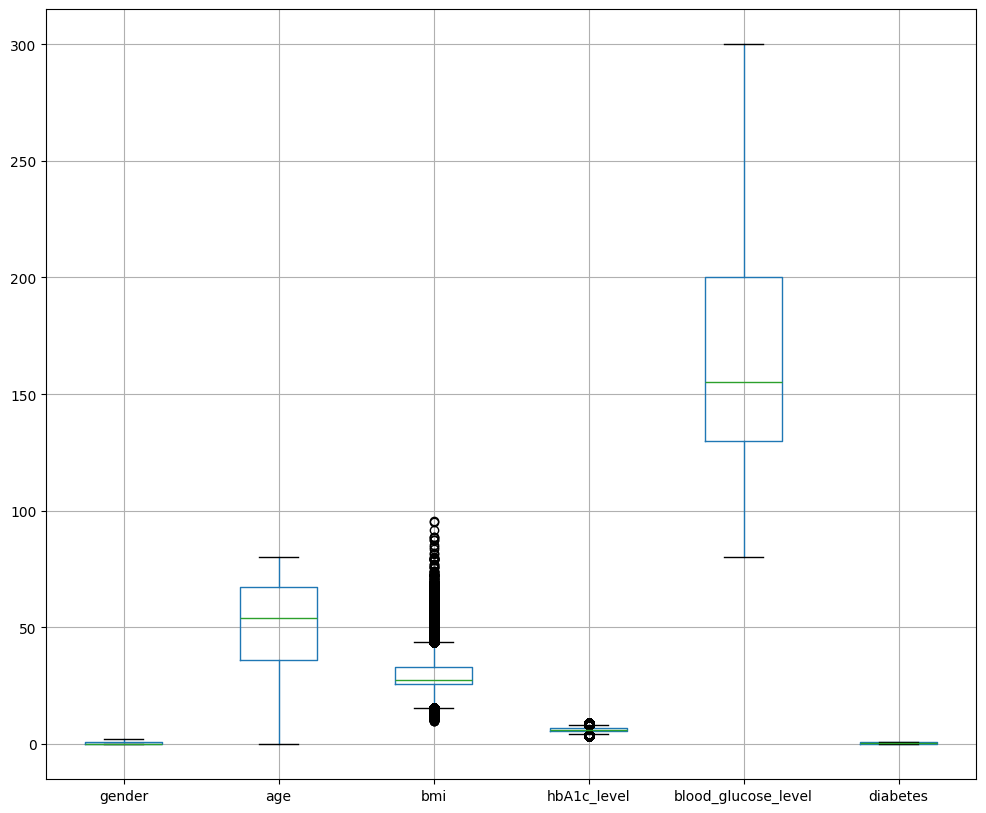

In [ ]:
df.boxplot(figsize=(12,10))

### **Removing Outliers**

In [ ]:
def remove_outliers_iqr(df, exclude_column):
  for col in df.columns:
    if col ==exclude_column:
      continue

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3-Q1
    lower_bound = Q1-1.5*IQR
    upper_bound =Q3+1.5*IQR

    df = df[(df[col] >= lower_bound) & (df[col] <=upper_bound)]
  return df


df_cleaned = remove_outliers_iqr(df, exclude_column='diabetes')
df = df_cleaned


## Logistic Regression


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

x = df[['gender','age','bmi','hbA1c_level','blood_glucose_level']]
y = df['diabetes']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state=42)

model = LogisticRegression()
model.fit(x_train,y_train)

y_pred = model.predict(x_test)
accuracy = accuracy_score(y_test, y_pred)
print(f'Baseline Model accuracy: {accuracy:.2f}')

Baseline Model accuracy: 0.88


## **Decision Tree**

In [ ]:
from sklearn.tree import DecisionTreeClassifier

x = df[['gender','age','bmi','hbA1c_level','blood_glucose_level']]
y = df['diabetes']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state=42)

model = DecisionTreeClassifier()
model.fit(x_train,y_train)

y_pred = model.predict(x_test)
accuracy = accuracy_score(y_test, y_pred)
print(f'Baseline Model accuracy: {accuracy:.2f}')

Baseline Model accuracy: 0.95


## **Random Forest**

In [ ]:
from sklearn.ensemble import RandomForestClassifier

x = df[['gender','age','bmi','hbA1c_level','blood_glucose_level']]
y = df['diabetes']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state=42)

model = RandomForestClassifier()
model.fit(x_train,y_train)

y_pred = model.predict(x_test)
accuracy = accuracy_score(y_test, y_pred)
print(f'Baseline Model accuracy: {accuracy:.2f}')

Baseline Model accuracy: 0.96


## **SVC**

In [ ]:
from sklearn.pipeline import Pipeline #using linear svc bcz of large data
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC

x = df[['gender','age','bmi','hbA1c_level','blood_glucose_level']]
y = df['diabetes']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state=42)

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("Classifier", LinearSVC(random_state=42))
])
pipeline.fit(x_train, y_train)

y_pred = pipeline.predict(x_test)

accuracy = accuracy_score(y_test, y_pred)
print(f'Baseline Model accuracy: {accuracy:.2f}')



Baseline Model accuracy: 0.88


## **Deep Learning**

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Flatten
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from tensorflow.keras.metrics import SparseCategoricalAccuracy



In [ ]:
model = Sequential()
model.add(Dense(96, input_shape=(5,), activation='relu'))
model.add(Dense(64, activation ='relu' ))
model.add(Dense(32, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(loss='binary_crossentropy',optimizer='adam', metrics=['accuracy'])

In [ ]:
model.fit(x_train, y_train, epochs=50, batch_size=32)

Epoch 1/50
3441/3441 ━━━━━━━━━━━━━━━━━━━━ 12s 4ms/step - accuracy: 0.8996 - loss: 0.2110
Epoch 2/50
3441/3441 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.8991 - loss: 0.2101
Epoch 3/50
3441/3441 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.8999 - loss: 0.2080
Epoch 4/50
3441/3441 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - accuracy: 0.8971 - loss: 0.2126
Epoch 5/50
3441/3441 ━━━━━━━━━━━━━━━━━━━━ 14s 4ms/step - accuracy: 0.9000 - loss: 0.2082
Epoch 6/50
3441/3441 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.8977 - loss: 0.2114
Epoch 7/50
3441/3441 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.8985 - loss: 0.2086
Epoch 8/50
3441/3441 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.8981 - loss: 0.2112
Epoch 9/50
3441/3441 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.8973 - loss: 0.2106
Epoch 10/50
3441/3441 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.8999 - loss: 0.2094
Epoch 11/50
3441/3441 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.8998 - loss: 0.2078
Epoch 12/50
3441/3441 

In [ ]:
probs = model.predict(np.expand_dims(x_test.iloc[0], axis=0))

pred_classes = np.round(probs).astype(int)

print("Probabilities:\n", probs.flatten())
print()
print("Predicted Classes (by rounding):", pred_classes.flatten())

In [ ]:
# Evaluating the model

loss, accuracy = model.evaluate(X_test, Y_test)
print(f"Model Accuracy: {accuracy * 100:.2f}%")

## **Confusion Matrix**

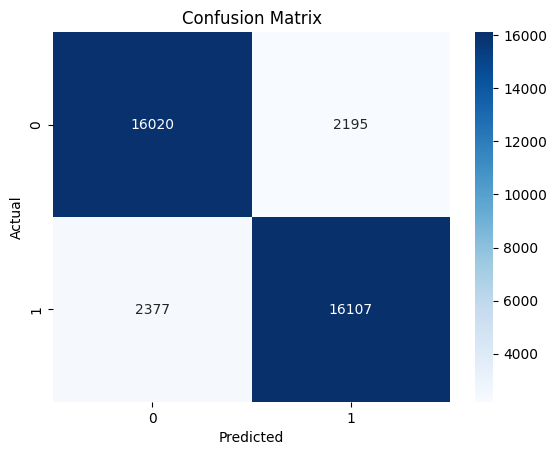

In [ ]:
from sklearn.metrics import confusion_matrix

# Calculate the confusion matrix using the actual and predicted values
cm = confusion_matrix(y_test, y_pred)

# Plot the heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [ ]:
import pickle
with open("Diabetes_Detection_model.pkl","wb")as file:
  pickle.dump(pipeline,file)

# **CONCLUSION**

In conclusion, this project successfully demonstrated the application of both traditional machine learning and deep learning techniques to predict diabetes status using demographic and clinical features from a large patient dataset. Multiple models, including Logistic Regression, Random Forest, and Support Vector Classifier (SVC), were trained and evaluated using confusion matrices to assess their performance. Among these, the Random Forest model showed robust predictive accuracy and reliable handling of complex feature interactions. The final selected model was saved in pickle format, enabling easy deployment for future predictions. Overall, this study highlights the potential of combining clinical and demographic data with machine learning to support early detection, risk stratification, and data-driven decision-making in diabetes management.

